In [1]:
import numpy as np 
import pandas as pd

import os
dir_beserah = os.path.join('../input/datasets/inovasijb/dataset/dataset/Siri Beserah')
dir_bunggor = os.path.join('../input/datasets/inovasijb/dataset/dataset/Siri Bunggor')
dir_durian = os.path.join('../input/datasets/inovasijb/dataset/dataset/Siri Durian')
dir_hollyrood = os.path.join('../input/datasets/inovasijb/dataset/dataset/Siri Hollyrood')
dir_jerangau = os.path.join('../input/datasets/inovasijb/dataset/dataset/Siri Jerangau')
dir_lambak = os.path.join('../input/datasets/inovasijb/dataset/dataset/Siri Lambak')
dir_localaluvium = os.path.join('../input/datasets/inovasijb/dataset/dataset/Siri Local Aluvium')
dir_melaka = os.path.join('../input/datasets/inovasijb/dataset/dataset/Siri Melaka')
dir_renggam = os.path.join('../input/datasets/inovasijb/dataset/dataset/Siri Renggam')

This is folder based data or directory based and thus the images are in folders that are again in main folder. This creates a problem of accessing the image data which aren't augmented.<br>
The Keras has ImageDataGenerator class which generate batches of tensor image data with real-time data augmentation. The data will be looped over (in batches). Basically, it can be used to augment image data with a lot of built-in pre-processing.

In [2]:
import tensorflow as tf
from tensorflow import keras

In [3]:
image_size = 220
batch_size = 1


target_size = (image_size, image_size)
input_shape = (image_size, image_size, 3)

In this, the flow_from_directory method automatically scans through all the sub-directories and sources the images along with their appropriate labels.

In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(rescale=1/255)


train_generator = train_datagen.flow_from_directory(
        '/kaggle/input/datasets/inovasijb/dataset/dataset/', 
        target_size=(200, 200),
        batch_size = batch_size,
        classes = ['Siri Beserah','Siri Bunggor','Siri Durian','Siri Hollyrood','Siri Jerangau','Siri Lambak','Siri Local Aluvium','Siri Melaka','Siri Renggam'],
       class_mode='categorical')

Found 58 images belonging to 9 classes.


In [5]:
for image_batch, label_batch in train_generator:
  break
  image_batch.shape, label_batch.shape

In [6]:
print (train_generator.class_indices)

{'Siri Beserah': 0, 'Siri Bunggor': 1, 'Siri Durian': 2, 'Siri Hollyrood': 3, 'Siri Jerangau': 4, 'Siri Lambak': 5, 'Siri Local Aluvium': 6, 'Siri Melaka': 7, 'Siri Renggam': 8}


In [7]:
from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import Conv2D

model = tf.keras.models.Sequential([
    
    Input(shape=(220,220,3)),
    # The first convolution
    tf.keras.layers.Conv2D(16, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    # The second convolution
    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    # The third convolution
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    # The fourth convolution
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    # The fifth convolution
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    
    # Flatten the results to feed into a dense layer
    tf.keras.layers.Flatten(),
    # 128 neuron in the fully-connected layer
    tf.keras.layers.Dense(128, activation='relu'),
    # 7 output neurons for 5 classes with the softmax activation
    tf.keras.layers.Dense(9, activation='softmax')
])



2026-08-08 11:20:18.800698: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 218, 218, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 109, 109, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 107, 107, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 53, 53, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 51, 51, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 23, 23, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 11, 11, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 9, 9, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 229,801 (897.66 KB)

 Trainable params: 229,801 (897.66 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
print(label_batch.shape)

(1, 9)


In [10]:
from tensorflow.keras.optimizers import RMSprop

model.compile(loss='categorical_crossentropy',
              optimizer=RMSprop(learning_rate=0.001),
              metrics=['acc'])

In [11]:
total_sample = train_generator.n
n_epochs = 100

In [12]:
history = model.fit(
        train_generator, 
        steps_per_epoch = int(total_sample/batch_size),  
        epochs = n_epochs,
        verbose = 1)

Epoch 1/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - acc: 0.1552 - loss: 2.2157
Epoch 2/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - acc: 0.1897 - loss: 2.2755
Epoch 3/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - acc: 0.1897 - loss: 2.2079
Epoch 4/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - acc: 0.1207 - loss: 2.2145
Epoch 5/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - acc: 0.1724 - loss: 2.2142
Epoch 6/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - acc: 0.1897 - loss: 2.2005
Epoch 7/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - acc: 0.1897 - loss: 2.1786
Epoch 8/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - acc: 0.1897 - loss: 2.1489
Epoch 9/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - acc: 0.1897 - loss: 2.0575
Epoch 10/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - acc: 0.2241 - loss: 2.0886
Epoch 11/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - acc: 0.2414 - loss: 2.0029
Epoch 12/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - acc: 0.2586 - loss: 1.9825
Epoch 13/100
58/58 ━━━━━━

In [13]:
import matplotlib.pyplot as plt

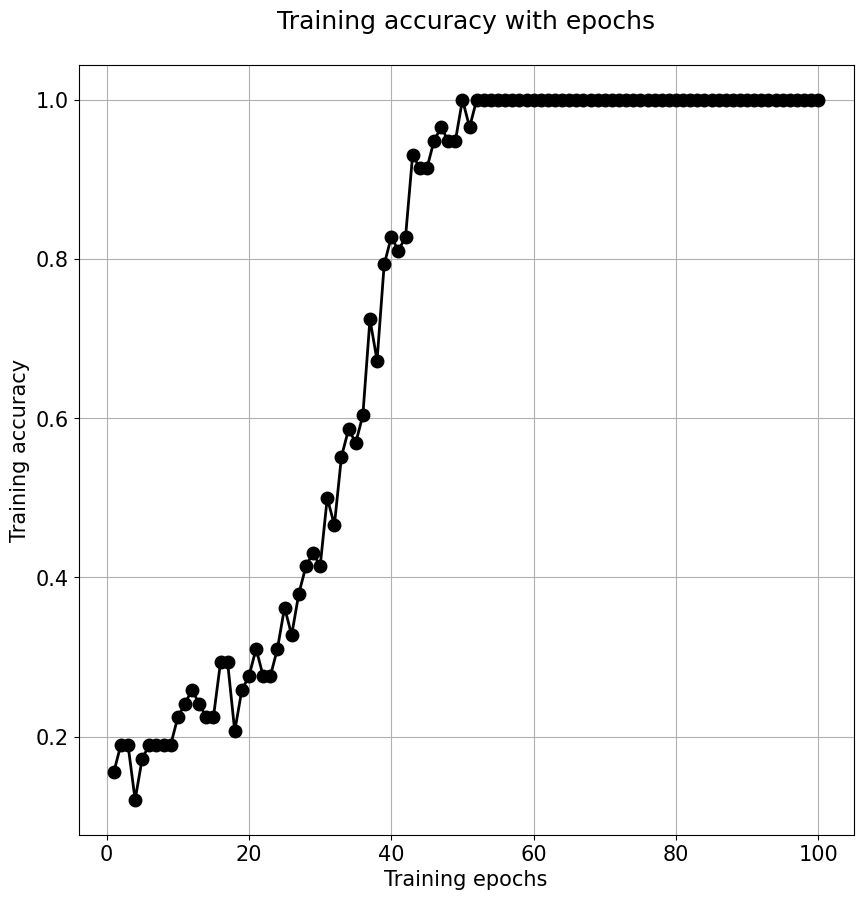

In [14]:
plt.figure(figsize=(10,10))
plt.plot([i+1 for i in range(n_epochs)],history.history['acc'],'-o',c='k',lw=2,markersize=9)
plt.grid(True)
plt.title("Training accuracy with epochs\n",fontsize=18)
plt.xlabel("Training epochs",fontsize=15)
plt.ylabel("Training accuracy",fontsize=15)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.show()

**Some ways to save the model...**

The saved model formats can be used to continue with the model preparation without actually starting from the beginning.<br>
The saved model files can be used to deploy the model in android or web applications.

In [15]:
model.save('model.h5')

In [16]:
model.save(filepath="save_model/")

ValueError: Invalid filepath extension for saving. Please add either a `.keras` extension for the native Keras format (recommended) or a `.h5` extension. Use `model.export(filepath)` if you want to export a SavedModel for use with TFLite/TFServing/etc. Received: filepath=save_model/.

In [ ]:
from tensorflow.keras.models import Sequential
model.export(export_dir='.')

In [ ]:
converter = tf.lite.TFLiteConverter.from_saved_model('save_model')
tflite_model = converter.convert()
open("model.tflite", "wb").write(tflite_model)

In [ ]:
model.save_weights("model.h5")

In [ ]:
#  tf.keras.models.save_model(model, filepath="save_model/save_model")

In [ ]:
import tensorflow as tf

# 1. Load the h5 model
model = tf.keras.models.load_model('model.h5')

# 2. Convert the model to TFLite format
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# 3. Save the tflite file
with open('model.tflite', 'wb') as f:
    f.write(tflite_model)


In [ ]:
!git config --global user.name "inovasijb"
!git config --global user.email "inovasijbwiralestari@gmail.com"

!git clone https://github.com/inovasijb/wsl.git

!cp model.tflite wsl/assets/

import os
token = os.environ["GITHUB_TOKEN"]

    
cd wsl
!git add assets/model.tflite
!git commit -m "Push updated model.tflite from kaggle"

# Use PAT instead of password
!git push https://{token}@github.com/inovasijb/wsl.git main
